# Deeper exploration of photometry

In writing up paper 1, I found that there was an excess of faint long-wavelength, or a deficiency of faint short-wavelength, sources toward the Brick.

I'd like to investigate that here more deeply by comparing two small subfields in detail and seeing what the cataloger did (not) recover.


See [ColorVsCOiceAnalysis.ipynb#Check_the_source_density](ColorVsCOiceAnalysis.ipynb#Check_the_source_density)

In [1]:
cd /orange/adamginsburg/jwst/brick/

/blue/adamginsburg/adamginsburg/jwst/brick


In [2]:
%matplotlib inline
import pylab as pl

In [3]:
basepath = '/orange/adamginsburg/jwst/brick/'

In [4]:
import sys
if '' in sys.path:
    sys.path.remove('')

In [5]:
%run $basepath/analysis/analysis_setup.py

/orange/adamginsburg/jwst/brick/analysis/analysis_setup.py:4: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import sys, imp
/orange/adamginsburg/jwst/brick/analysis/analysis_setup.py:19: DeprecationWarning: `photutils.CircularAperture` is a deprecated alias for `photutils.aperture.CircularAperture` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAperture` to silence this warning.
  from photutils import CircularAperture, EPSFBuilder, find_peaks, CircularAnnulus
/orange/adamginsburg/jwst/brick/analysis/analysis_setup.py:19: DeprecationWarning: `photutils.EPSFBuilder` is a deprecated alias for `photutils.psf.EPSFBuilder` and will be removed in the future. Instead, please use `from photutils.psf import EPSFBuilder` to silence this warning.
  from photutils import CircularAperture, EPSFBuilder, find_peaks, CircularAnnulus
/orange/adamginsburg/jwst/brick/analysis/a

For module nrca catalog crowdsource_nsky0_nrca_photometry_tables_merged.fits, mod date is 2023-10-04 02:28:35
For module nrcb catalog crowdsource_nsky0_nrcb_photometry_tables_merged.fits, mod date is 2023-10-04 04:16:32
For module merged catalog crowdsource_nsky0_merged_photometry_tables_merged.fits, mod date is 2023-10-04 00:42:49
For module merged-reproject catalog crowdsource_nsky0_merged-reproject_photometry_tables_merged.fits, mod date is 2023-10-03 22:02:09


In [6]:
%run $basepath/analysis/selections.py --module=merged-reproject

/orange/adamginsburg/jwst/brick/analysis/selections.py:17: DeprecationWarning: `photutils.CircularAperture` is a deprecated alias for `photutils.aperture.CircularAperture` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAperture` to silence this warning.
  from photutils import CircularAperture, EPSFBuilder, find_peaks, CircularAnnulus
/orange/adamginsburg/jwst/brick/analysis/selections.py:17: DeprecationWarning: `photutils.EPSFBuilder` is a deprecated alias for `photutils.psf.EPSFBuilder` and will be removed in the future. Instead, please use `from photutils.psf import EPSFBuilder` to silence this warning.
  from photutils import CircularAperture, EPSFBuilder, find_peaks, CircularAnnulus
/orange/adamginsburg/jwst/brick/analysis/selections.py:17: DeprecationWarning: `photutils.find_peaks` is a deprecated alias for `photutils.detection.find_peaks` and will be removed in the future. Instead, please use `from photutils.detection import find_p

For module nrca catalog crowdsource_nsky0_nrca_photometry_tables_merged.fits, mod date is 2023-10-04 02:28:35
For module nrcb catalog crowdsource_nsky0_nrcb_photometry_tables_merged.fits, mod date is 2023-10-04 04:16:32
For module merged catalog crowdsource_nsky0_merged_photometry_tables_merged.fits, mod date is 2023-10-04 00:42:49
For module merged-reproject catalog crowdsource_nsky0_merged-reproject_photometry_tables_merged.fits, mod date is 2023-10-03 22:02:09
Selecting module merged-reproject

NRCA
612 saturated in near_saturated_f212n_f212n
26 saturated in near_saturated_f466n_f466n
58 saturated in near_saturated_f405n_f405n
278 saturated in near_saturated_f187n_f187n
2757 saturated in near_saturated_f182m_f182m
3675 near saturated out of 295443.  That leaves 291768 not near unsaturated
70 saturated in replaced_saturated_f212n
10 saturated in replaced_saturated_f466n
31 saturated in replaced_saturated_f405n
19 saturated in replaced_saturated_f187n
117 saturated in replaced_saturat

In [7]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm

In [8]:
def overplot_catalog_on_regions(reg, max_percent=99.95):
    pl.figure(figsize=(12,6), dpi=150)
    for ii, filtername in enumerate(sorted(filternames)):
        fh = fits.open(f'{filtername.upper()}/pipeline/jw02221-o001_t001_nircam_clear-{filtername}-merged-reproject_i2d.fits')
        ww = WCS(fh['SCI'].header)
        preg = reg.to_pixel(ww)
        mask = preg.to_mask()
        data = fh['SCI'].data
        cutout = mask.cutout(data)
        slices, _ = mask.get_overlap_slices(data.shape)
        ww_cutout = ww[slices]

        ax = pl.subplot(2, 3, ii+1, projection=ww_cutout)
        ax.imshow(cutout, norm=simple_norm(cutout, max_percent=max_percent, min_cut=-0.5, stretch='log'), cmap='gray_r')
        ax.set_title(filtername)

        ax.coords['ra'].set_ticklabel_visible(False)
        ax.coords['dec'].set_ticklabel_visible(False)
        ax.coords['ra'].set_axislabel('')
        ax.coords['dec'].set_axislabel('')

        crd = basetable[f'skycoord_{filtername}']
        sel = reg.contains(crd, ww)
        ax.scatter_coord(crd[sel], marker='x', color='r', edgecolors='r', s=3, linewidth=0.5, facecolor='none')
        sel &= (~any_saturated) & (any_good) & long_good & ~bad
        ax.scatter_coord(crd[sel], marker='x', color='b', edgecolors='b', s=3, linewidth=0.5, facecolor='none')
        
    pl.tight_layout()

# Zoom field 1: the Brick Line Survey pointing

In [9]:
import regions
reg = clusterreg = regions.Regions.read('regions/cluster_square.reg')[0]
clusterreg_zoom = regions.Regions.read('regions/cluster_square_zoom.reg')[0]
reg

<RectangleSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (266.54353967, -28.70557936)>, width=17.3411 arcsec, height=15.146 arcsec, angle=0.0 deg)>

In these plots, red are all crowdsource-ID'd points, blue are those detected in all longwave filters

/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/as

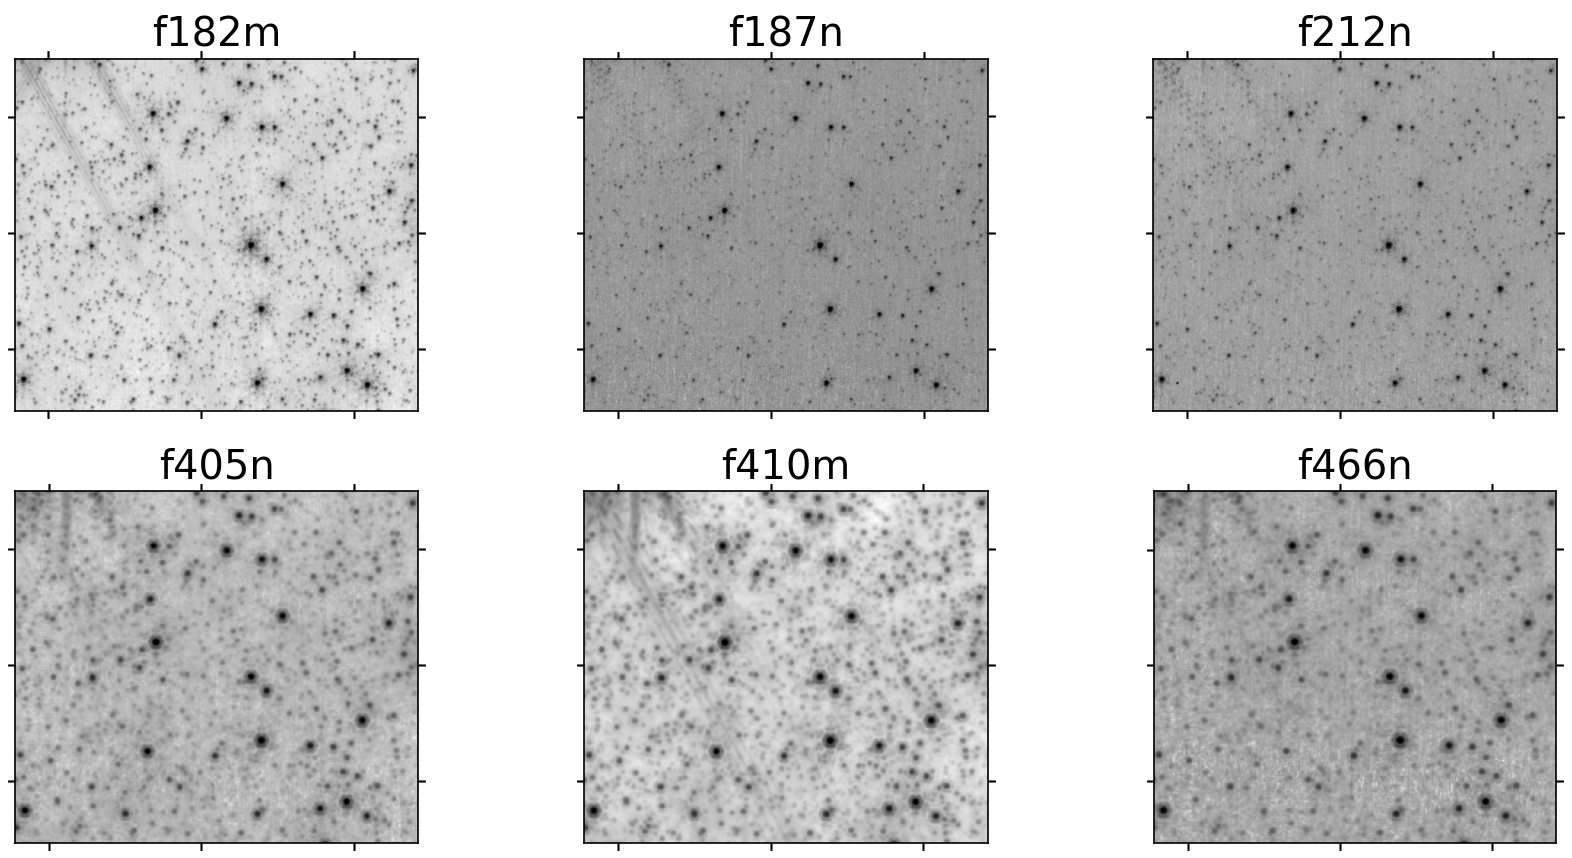

In [10]:
overplot_catalog_on_regions(clusterreg)

/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/as

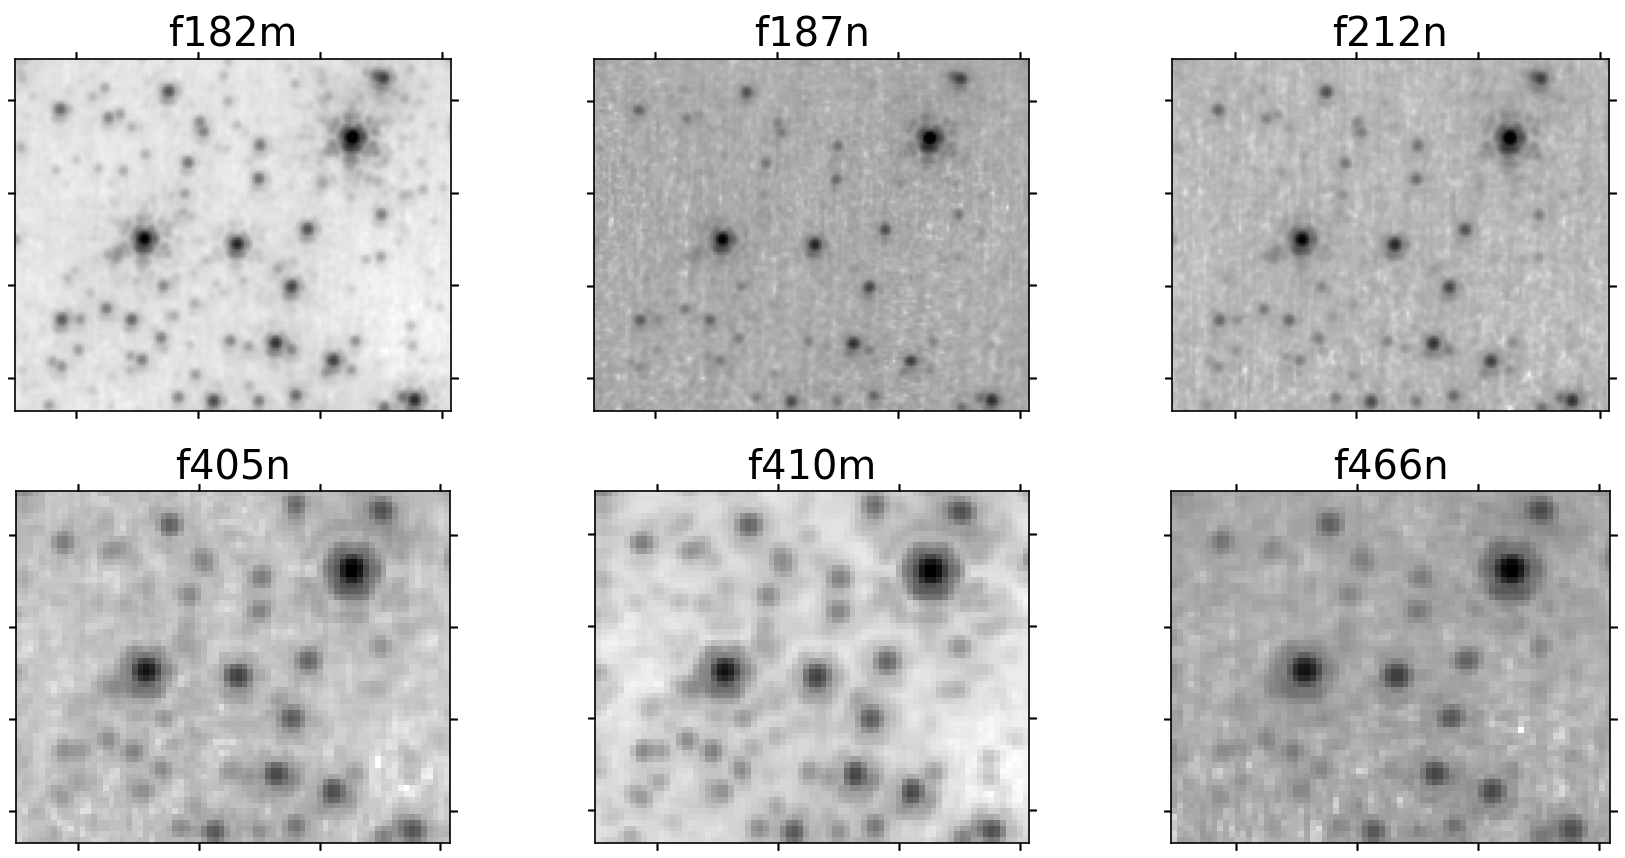

In [11]:
overplot_catalog_on_regions(clusterreg_zoom)

# Zoom Field 2: A field with some bright stars and high star density

In [12]:
import regions
reg = nrcb_bright_reg = regions.Regions.read('regions/bright_star_field_nrcb.reg')[0]
nrcb_bright_reg_zoom = regions.Regions.read('regions/bright_star_field_nrcb_zoom.reg')[0]
reg

<RectangleSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (266.54927311, -28.68442914)>, width=17.3411 arcsec, height=15.146 arcsec, angle=0.0 deg)>

/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/as

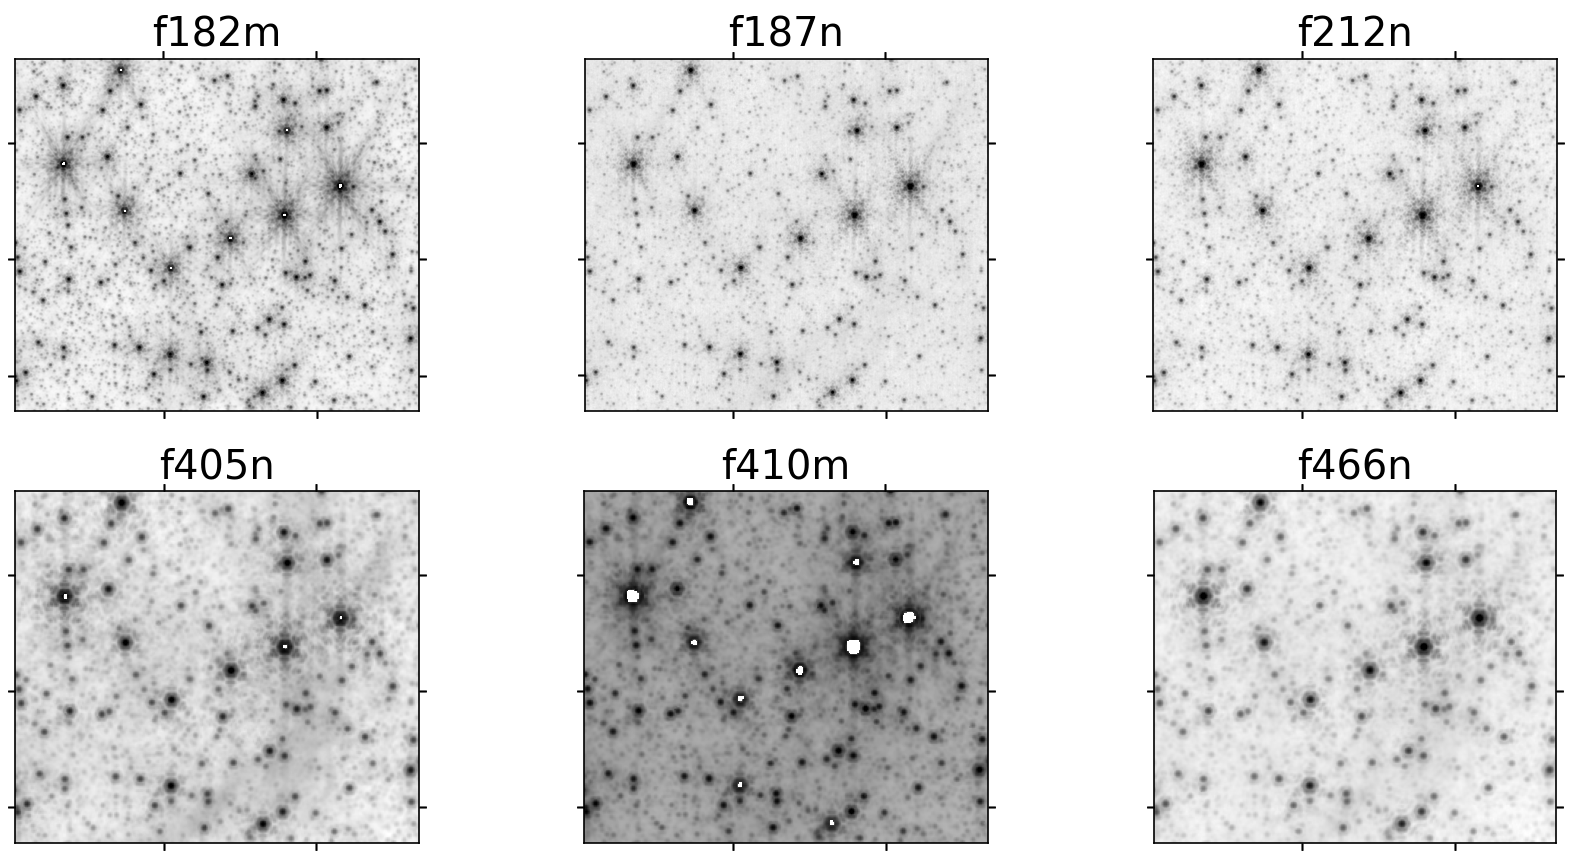

In [13]:
overplot_catalog_on_regions(nrcb_bright_reg)

/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/astropy/astropy/visualization/wcsaxes/core.py:386: UserWarning: You passed a edgecolor/edgecolors ('r') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return super().scatter(*args, **kwargs)
/blue/adamginsburg/adamginsburg/repos/as

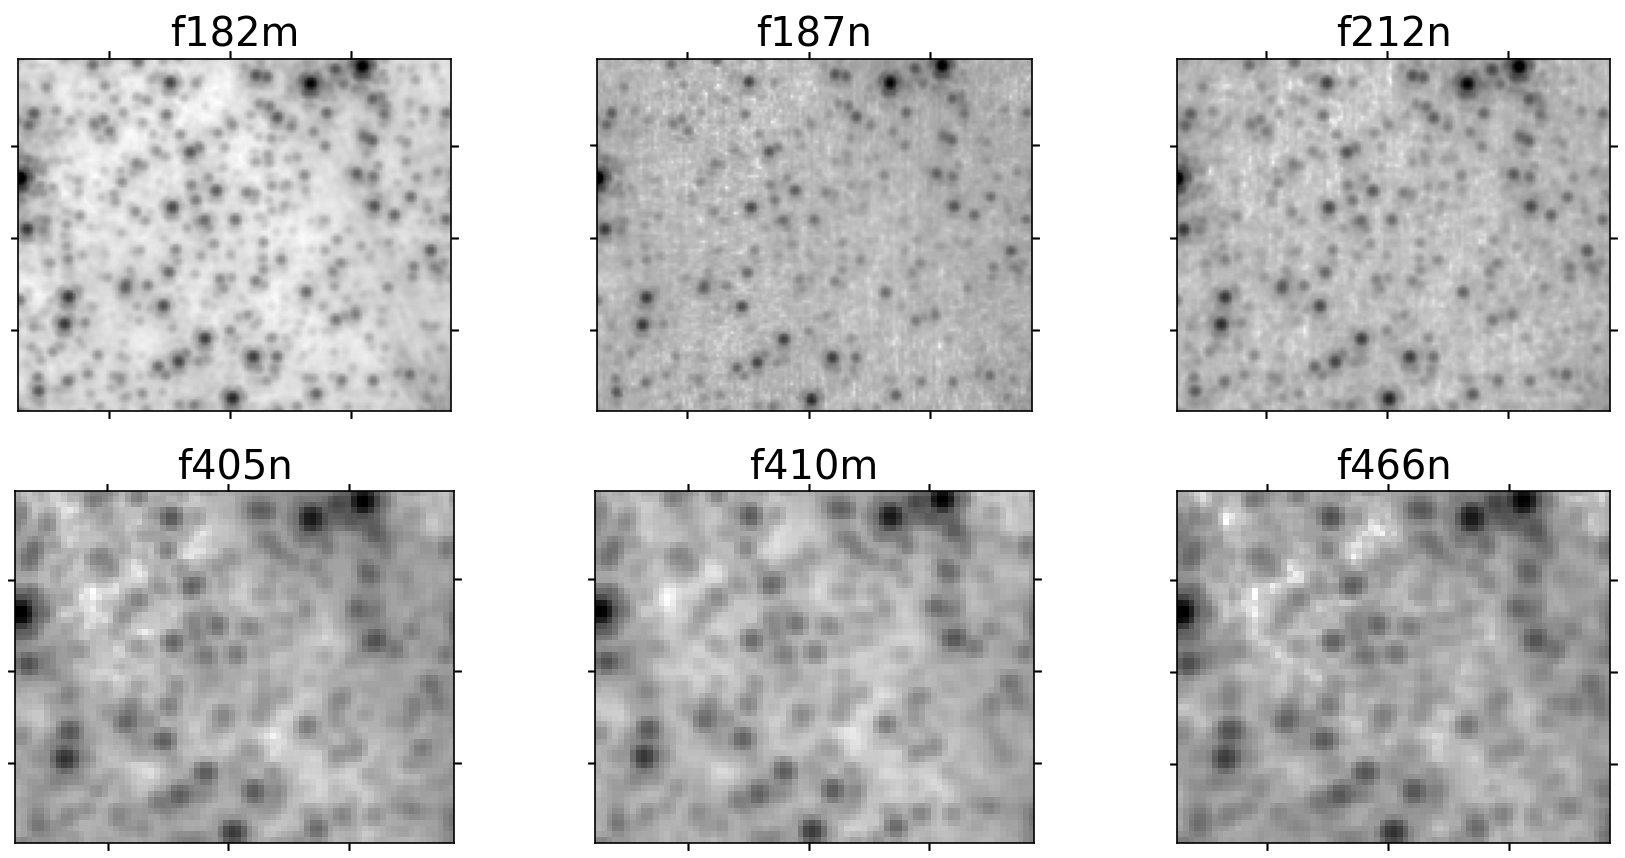

In [14]:
overplot_catalog_on_regions(nrcb_bright_reg_zoom)